# **Проект модуля. Нейросеть для автодополнения текстов.**


## **Этап 1.Сбор и подготовка данных**
1. Скачайте датасет, положите его в папку data.
    
2. «Почистите» тексты в датасете, а затем токенизируйте их. Для удобства можете сохранить почищенный и токенизированный датасет.

3. Разбейте датасет на трейн, валидацию и тест.
    
4. Создайте torch.Dataset и torch.DataLoader для обучения модели.

In [ ]:
import os

os.mkdir("data")

1. Неочищенный набор данных храниться в папке data и представлен двумя файлами - test_dataset_raw.csv, train_dataset_raw.csv

In [1]:
from src import download_and_extract

DATA_URL: str = "https://cs.stanford.edu/people/alecmgo/trainingandtestdata.zip"

data_path: str = "./data/"

download_and_extract(DATA_URL, data_path)

Скачивание архива...
Архив успешно скачан
Распаковка архива...
Архив успешно распакован в папку ./data/
Временный архив удален


2. Выполним очистку и токенизацию текста, сохранив результаты в clean_dataset.csv, clean_tokenized_dataset.csv в папке data

In [1]:
from src import preprocess_clean_dataset

input_file: str = "./data/training.1600000.processed.noemoticon.csv"
output_file: str = "./data/cleaned_dataset.csv"

# for train data
preprocess_clean_dataset(input_file, output_file)

Очищенные данные сохранены в ./data/cleaned_dataset.csv
Файл удален: ./data/training.1600000.processed.noemoticon.csv


In [2]:
# for test data
input_file = "./data/testdata.manual.2009.06.14.csv"
output_file = "./data/test_cleaned_dataset.csv"

preprocess_clean_dataset(input_file, output_file)

Очищенные данные сохранены в ./data/test_cleaned_dataset.csv
Файл удален: ./data/testdata.manual.2009.06.14.csv


Создадим токенизированный набор данных:

In [3]:
from src import save_tokenized_dataset

input_file = "./data/cleaned_dataset.csv"
output_file = "./data/dataset.csv"

save_tokenized_dataset(input_file, output_file)

Токенизированные данные сохранены в ./data/dataset.csv
Пример токенов: [101, 1037, 2008, 2015, 1037, 26352, 5017, 1012, 2017, 2323]...


In [4]:
from src import save_tokenized_dataset

input_file = "./data/test_cleaned_dataset.csv"
output_file = "./data/test.csv"

save_tokenized_dataset(input_file, output_file)

Токенизированные данные сохранены в ./data/test.csv
Пример токенов: [101, 1045, 2293, 2026, 2785, 2571, 1012, 2053, 2008, 1996]...


**3.Разделим данные на тренировочные и валидационные**

In [5]:
from src import split_dataset

input_file = "./data/dataset.csv"
train_file = "./data/train.csv"
val_file = "./data/val.csv"

split_dataset(input_file,
              train_file,
              val_file,
              val_size=0.1)

Train данных: 1437303
Val данных: 159701
Train сохранен в ./data/train.csv
Val сохранен в ./data/val.csv


Проанализируем набор данных для того, чтобы подобрать оптимальную длину последовательности:

=== СТАТИСТИКА ДЛИН ПОСЛЕДОВАТЕЛЬНОСТЕЙ ===
Общее количество последовательностей: 1437303
Средняя длина: 18.2
Медианная длина: 17.0
Минимальная длина: 3
Максимальная длина: 81
Стандартное отклонение: 8.8
25% перцентиль: 11.0
50% перцентиль: 17.0
75% перцентиль: 25.0
90% перцентиль: 31.0
95% перцентиль: 34.0
99% перцентиль: 38.0


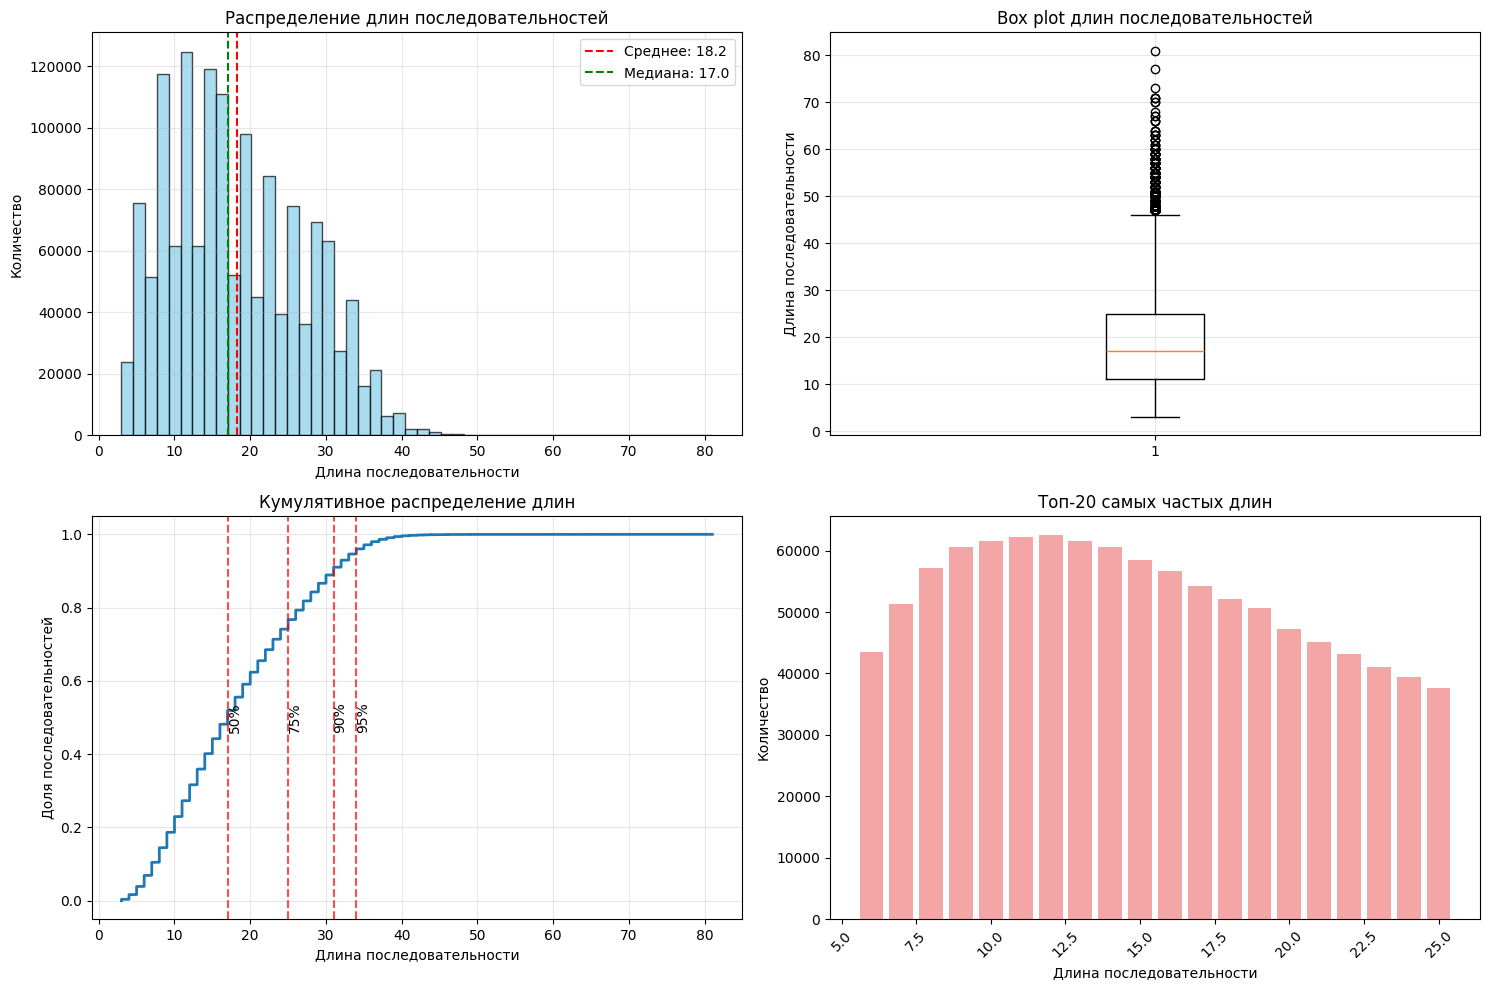


=== РЕКОМЕНДАЦИИ ПО ВЫБОРУ SEQUENCE_LENGTH ===
Покрытие данных для разных sequence_length:
sequence_length =   5:  98.3% данных (1413383 последовательностей)
sequence_length =  10:  81.3% данных (1168968 последовательностей)
sequence_length =  15:  59.9% данных (860377 последовательностей)
sequence_length =  20:  40.9% данных (588129 последовательностей)
sequence_length =  25:  25.9% данных (372131 последовательностей)
sequence_length =  30:  13.4% данных (192163 последовательностей)
sequence_length =  40:   0.6% данных ( 9037 последовательностей)
sequence_length =  50:   0.0% данных (  308 последовательностей)
sequence_length =  64:   0.0% данных (   17 последовательностей)
sequence_length = 128:   0.0% данных (    0 последовательностей)

Рекомендуемая sequence_length: 10
Это покроет 81.3% данных

При sequence_length = 10:
Будет потеряно 18.7% данных
Останется 1168968 последовательностей для обучения


In [6]:
from src import analyze_for_sequence

train_data: str = "./data/train.csv"

analyze_for_sequence(train_data)

In [1]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [7]:

from src import NextTokenDataset
from torch.utils.data import DataLoader

# Создаем dataset
dataset = NextTokenDataset(
    csv_file="./data/val.csv",  # val data
    sequence_length=7  # Длина контекста для предсказания
)

# Создаем DataLoader
dataloader = DataLoader(
    dataset,
    num_workers=4,
    persistent_workers=True,
    batch_size=64,
    shuffle=True)

# Проверяем данные
print("=== ПРОВЕРКА ДАТАСЕТА ===")
print(f"Всего примеров: {len(dataset)}")

# Несколько примеров
for i in range(3):
    sample_info = dataset.get_sample_info(i)
    print(f"\nПример {i}:")
    print(f"Input sequence: {sample_info['input_sequence'][:10]}...")  # Показываем первые 10 токенов
    print(f"Target token: {sample_info['target_token']}")
    print(f"Original text: {sample_info['original_text'][:100]}...")

# Проверяем батчи
print("\n=== ПРОВЕРКА БАТЧЕЙ ===")
for batch_idx, (inputs, targets) in enumerate(dataloader):
    print(f"Батч {batch_idx}:")
    print(f"  Inputs shape: {inputs.shape}")    # [32, sequence_length]
    print(f"  Targets shape: {targets.shape}")  # [32]
    
    if batch_idx >= 2:  # Показываем только первые 3 батча
        break

Создано 1806281 осмысленных примеров
=== ПРОВЕРКА ДАТАСЕТА ===
Всего примеров: 1806281

Пример 0:
Input sequence: [101, 7910, 2290, 2049, 2061, 7977, 1998]...
Target token: 1045
Original text: uhg its so gross and i wanted this to be a good weekend! well next weekend its of to wyomming yay i ...

Пример 1:
Input sequence: [7910, 2290, 2049, 2061, 7977, 1998, 1045]...
Target token: 2359
Original text: uhg its so gross and i wanted this to be a good weekend! well next weekend its of to wyomming yay i ...

Пример 2:
Input sequence: [2290, 2049, 2061, 7977, 1998, 1045, 2359]...
Target token: 2023
Original text: uhg its so gross and i wanted this to be a good weekend! well next weekend its of to wyomming yay i ...

=== ПРОВЕРКА БАТЧЕЙ ===


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Батч 0:
  Inputs shape: torch.Size([64, 7])
  Targets shape: torch.Size([64])
Батч 1:
  Inputs shape: torch.Size([64, 7])
  Targets shape: torch.Size([64])
Батч 2:
  Inputs shape: torch.Size([64, 7])
  Targets shape: torch.Size([64])


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


**4. Создадим torch.Dataset и torch.DataLoader**

In [ ]:
from src import NextTokenDataset
from torch.utils.data import DataLoader

train_data = "./data/train.csv"
val_data = "./data/val.csv"
test_data = "./data/test.csv"

train_dataset = NextTokenDataset(
    train_data,
    sequence_length=7,
    min_sequence_length=10
)

val_dataset = NextTokenDataset(
    val_data,
    sequence_length=7,
    min_sequence_length=10
)

train_loader = DataLoader(
    train_dataset,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    batch_size=256,
    prefetch_factor=2)

## Проверка
Проверим работоспособность кода обучения на маленькой выборке из датасета. Отдебажим нулевой запуск.

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, SubsetRandomSampler
from transformers import BertTokenizerFast

from src import NextTokenDataset

# Для начала взглянем на работоспособность модели на 50000 данных


train_data = "./data/train.csv"
val_data = "./data/val.csv"

# загружаем токенизатор
tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

# Датасеты
train_dataset = NextTokenDataset(
    train_data,
    sequence_length=7,
    min_sequence_length=10
)

train_indices = list(range(50000))

val_dataset = NextTokenDataset(
    val_data,
    sequence_length=7,
    min_sequence_length=10
)

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    batch_size=256,
    sampler=SubsetRandomSampler(train_indices),
    prefetch_factor=2)

val_loader = DataLoader(
    val_dataset,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    batch_size=256,
    prefetch_factor=2
)

print(f"Train dataset size: {len(train_dataset)}, Val dataset_size: {len(val_dataset)}")
print(f"Train loader size: {len(train_loader)}, Val loader size: {len(val_loader)}")

Создано 16714585 осмысленных примеров
Создано 1850975 осмысленных примеров
Train dataset size: 16714585, Val dataset_size: 1850975
Train loader size: 196, Val loader size: 7231


In [2]:
from src import (
    LSTMAutocomplete,  # модель
    evaluate_with_rouge, # метод оценки
    train_epoch) # метод для тренировки



# параметры и гиперпараметры для обучения:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

learning_rate = 0.001

vocab_size = tokenizer.vocab_size
hidden_dim = 128
embedding_dim=128
num_layers=3
dropout=0.2



model = LSTMAutocomplete(vocab_size,
                         embedding_dim,
                         hidden_dim,
                         num_layers,
                         dropout).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()


Модель инициализирована:
  Словарь: 30522
  Эмбеддинги: 128
  LSTM: 128 hidden, 3 layers


In [4]:
train_epoch(model, train_loader, optimizer, criterion, device)
evaluate_with_rouge(model,val_loader, tokenizer, device, 1)

Start epoch training!


Training!: 100%|##########| 196/196 [00:02<00:00, 76.89it/s]


Starting evaluation with ROUGE...


Evaluating: 100%|##########| 7231/7231 [00:36<00:00, 196.48it/s]


{'loss': 6.468745868906014,
 'accuracy': 0.08422263941976525,
 'rouge': {'rouge1': np.float64(0.9244391021324143),
  'rouge2': np.float64(0.9009971712087875),
  'rougeL': np.float64(0.9244850203500918),
  'rougeLsum': np.float64(0.9244089796710918)},
 'examples': [{'input_text': 'its soooo grosssss and',
   'predicted_word': '.',
   'true_next_word': 'i',
   'probability': 0.08151735365390778,
   'is_correct': False}]}

Как можно видеть, обучение проходит без сбоев, а значит есть смысл написать код для итогового запуска обучения на облаке:

# **Этапы 2-3**

- Класс нейронной сети реализован в модуле **src/lstm_model.py**

- Код обучения и оценки модели в процессе обучения описан в модуле **src/lstm_train.py, src/eval_lstm.py**

- Процесс управления обучением вынесен в модуль - **model_learning_process.py**

# Эксперименты с моделью:

## Основное обучение.

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from transformers import BertTokenizerFast

from src import NextTokenDataset

#1. Загрузка датасетов и DataLoaders
train_data = "./data/train.csv"
val_data = "./data/val.csv"

print("Формируем тренировочный Dataset")
train_dataset = NextTokenDataset(
    train_data,
    sequence_length=7,
    min_sequence_length=10
)
print("Успешно!")

print("Формируем валидационный Dataset")
val_dataset = NextTokenDataset(
    val_data,
    sequence_length=7,
    min_sequence_length=10
)
print("Успешно!")

# DataLoaders
print("Формируем тренировочный DataLoader")
train_loader = DataLoader(
    train_dataset,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    batch_size=256,
    prefetch_factor=2)

print("Успешно!")

print("Формируем валидационный DataLoader")
val_loader = DataLoader(
    val_dataset,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    batch_size=256,
    prefetch_factor=2
)
print("Успешно!")

print(f"Train dataset size: {len(train_dataset)}, Val dataset_size: {len(val_dataset)}")
print(f"Train loader size: {len(train_loader)}, Val loader size: {len(val_loader)}")

Формируем тренировочный Dataset
Создано 16131490 осмысленных примеров
Успешно!
Формируем валидационный Dataset
Создано 1786514 осмысленных примеров
Успешно!
Формируем тренировочный DataLoader
Успешно!
Формируем валидационный DataLoader
Успешно!
Train dataset size: 16131490, Val dataset_size: 1786514
Train loader size: 63014, Val loader size: 6979


In [4]:
# загружаем токенизатор на всякий случай повторно
tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

In [5]:
from src import LSTMAutocomplete

# параметры и гиперпараметры для обучения:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

learning_rate = 0.001
epochs = 5

vocab_size = tokenizer.vocab_size
hidden_dim = 128
embedding_dim=128
num_layers=3
dropout=0.2


model = LSTMAutocomplete(vocab_size,
                         embedding_dim,
                         hidden_dim,
                         num_layers,
                         dropout).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

Модель инициализирована:
  Словарь: 30522
  Эмбеддинги: 128
  LSTM: 128 hidden, 3 layers


Starting training for 5 epochs

Epoch 1/5
Start epoch training!


Training!: 100%|##########| 63014/63014 [12:59<00:00, 80.87it/s]


Starting evaluation with ROUGE...


Evaluating: 100%|##########| 6979/6979 [00:37<00:00, 188.18it/s]


Train Loss: 5.1279
Val Loss: 4.8053
Val Accuracy: 0.2072
ROUGE-1: 0.9080
ROUGE-2: 0.8875
ROUGE-L: 0.9081

Epoch 2/5
Start epoch training!


...

Train Loss: 4.7912
Val Loss: 4.6437
Val Accuracy: 0.2230
ROUGE-1: 0.9089
ROUGE-2: 0.8886
ROUGE-L: 0.9090

Epoch 5/5
Start epoch training!


Training!: 100%|##########| 63014/63014 [12:59<00:00, 80.85it/s]


Starting evaluation with ROUGE...


Evaluating: 100%|##########| 6979/6979 [00:36<00:00, 191.98it/s]


Train Loss: 4.7721
Val Loss: 4.6273
Val Accuracy: 0.2247
ROUGE-1: 0.9091
ROUGE-2: 0.8888
ROUGE-L: 0.9091

ОБУЧЕНИЕ ЗАВЕРШЕНО!
Графики сохранены в training_results.png


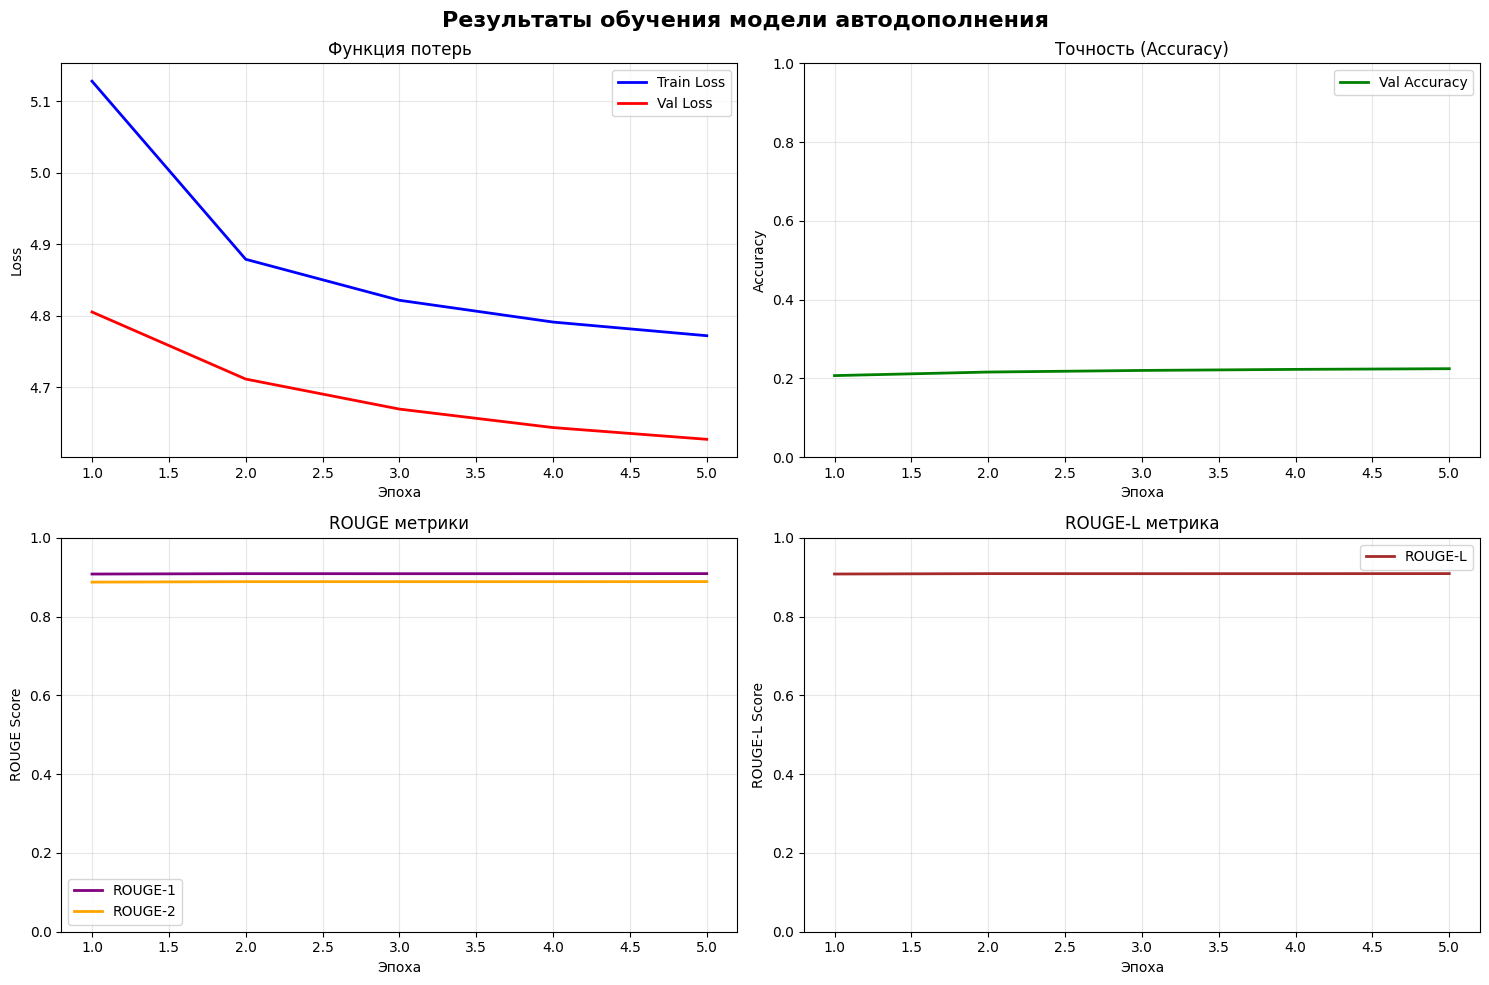


ИТОГОВЫЕ МЕТРИКИ ОБУЧЕНИЯ
Количество эпох: 5
Финальный Train Loss: 4.7721
Финальный Val Loss: 4.6273
Финальная Accuracy: 0.2247
Финальный ROUGE-1: 0.9091
Финальный ROUGE-2: 0.8888
Финальный ROUGE-L: 0.9091

Улучшение за обучение:
  Loss: +0.3558
  Accuracy: +0.0175
  ROUGE-1: +0.0010


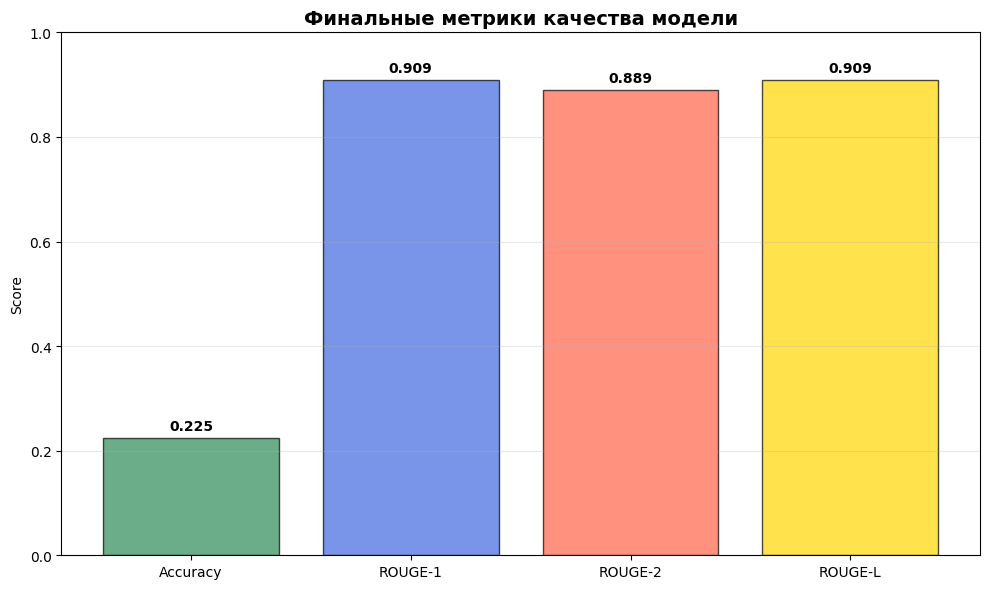


ПРИМЕРЫ ГЕНЕРАЦИИ - ЭПОХА 5

Пример 1: ✅ ПРАВИЛЬНО
Вход: '##k to bein a celebrity.'
Предсказано: '.' (вероятность: 0.371)
Ожидалось: '.'
Совпадение: True

Пример 2: ❌ НЕПРАВИЛЬНО
Вход: 'bed. my plan for the next'
Предсказано: 'days' (вероятность: 0.100)
Ожидалось: 'hours'
Совпадение: False

Пример 3: ❌ НЕПРАВИЛЬНО
Вход: 'getting worse. gonna call the doctor'
Предсказано: '.' (вероятность: 0.120)
Ожидалось: 'again'
Совпадение: False

Пример 4: ❌ НЕПРАВИЛЬНО
Вход: 'to wyomming yay i'
Предсказано: 'have' (вероятность: 0.080)
Ожидалось: 'think'
Совпадение: False

Пример 5: ❌ НЕПРАВИЛЬНО
Вход: 'drive to that frikkin lake'
Предсказано: '##r' (вероятность: 0.093)
Ожидалось: ''
Совпадение: False


In [6]:
from src import train_complete_with_plots, save_model_with_metadata

# Запускаем обучение
results = train_complete_with_plots(
    model,
    train_loader,
    val_loader,
    tokenizer,
    optimizer,
    criterion,
    device,
    epochs
)

Модель недообучается. Учится медленно.

- ROUGE метрики отличные (0.90+) - модель якобы хорошо сохраняет контекст, но, это указывает на проблему с учетом низких остальных метрик. Возможно, имеет место не верный расчет этой метрики, и нужно следить лишь за её флуктуациями вокруг максимального значения. Следует подправить код. Можно заключить, что ROUGE метрика в данном случае практически не меняется и модель учится очень медленно, если учится вообще. 

- Val Loss ниже Train Loss - нет переобучения

- Accuracy 22.5% - неплохо для 5 эпох и большого словаря (30K+ токенов)

Что можно улучшить:

- Accuracy низкая - модель угадывает только каждое 4-5 слово

- Loss высокий - модель еще не сошлась

- Замена характера оценки ROUGE

Пока изменим параметры обучения:
Увеличим длину подаваемого контекста,

Расширим слой, но уменьшим число слоев, так модель возможно сможет схватывать больше мелких деталей, что является спецификой нашего набора данных

Увеличим регуляризацию, уменьшим learning_rate

Попробуем учить дольше - 10 эпох, однако мелкими батчами по 128 последовательностей.

In [ ]:
# параметры и гиперпараметры для обучения:
sequence_length = 11  # вместо 7
hidden_dim = 256      # вместо 128
embedding_dim = 256   # вместо 128  
num_layers = 2        # вместо 3 (меньше слоев, но больше нейронов)
dropout = 0.3         # вместо 0.2
learning_rate = 0.0005  # уменьшить LR
epochs = 10            # больше эпох
batch_size = 128       # можно уменьшить для стабильности


## 2 попытка

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from transformers import BertTokenizerFast

from src import NextTokenDataset

#1. Загрузка датасетов и DataLoaders
train_data = "./data/train.csv"
val_data = "./data/val.csv"

print("Формируем тренировочный Dataset")
train_dataset = NextTokenDataset(
    train_data,
    sequence_length=sequence_length,
    min_sequence_length=12
)
print("Успешно!")

print("Формируем валидационный Dataset")
val_dataset = NextTokenDataset(
    val_data,
    sequence_length=sequence_length,
    min_sequence_length=12
)
print("Успешно!")

# DataLoaders
print("Формируем тренировочный DataLoader")
train_loader = DataLoader(
    train_dataset,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    batch_size=256,
    prefetch_factor=2)

print("Успешно!")

print("Формируем валидационный DataLoader")
val_loader = DataLoader(
    val_dataset,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    batch_size=256,
    prefetch_factor=2
)
print("Успешно!")

print(f"Train dataset size: {len(train_dataset)}, Val dataset_size: {len(val_dataset)}")
print(f"Train loader size: {len(train_loader)}, Val loader size: {len(val_loader)}")

Формируем тренировочный Dataset
Создано 11517261 осмысленных примеров
Успешно!
Формируем валидационный Dataset
Создано 1273680 осмысленных примеров
Успешно!
Формируем тренировочный DataLoader
Успешно!
Формируем валидационный DataLoader
Успешно!
Train dataset size: 11517261, Val dataset_size: 1273680
Train loader size: 44990, Val loader size: 4976


In [3]:
from src import LSTMAutocomplete


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# загружаем токенизатор на всякий случай повторно
tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")
vocab_size = tokenizer.vocab_size

# загружаем модель, оптимизатор, лосс функцию
model = LSTMAutocomplete(vocab_size,
                         embedding_dim,
                         hidden_dim,
                         num_layers,
                         dropout).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

Модель инициализирована:
  Словарь: 30522
  Эмбеддинги: 256
  LSTM: 256 hidden, 2 layers


Starting training for 10 epochs

Epoch 1/10
Start epoch training!


Training!: 100%|##########| 44990/44990 [12:30<00:00, 59.93it/s]


Starting evaluation with ROUGE...


Evaluating: 100%|##########| 4976/4976 [00:24<00:00, 206.44it/s]


Train Loss: 5.0302
Val Loss: 4.6758
Val Accuracy: 0.2227
ROUGE-1: 0.9406
ROUGE-2: 0.9326
ROUGE-L: 0.9405

Epoch 2/10
Start epoch training!


...

Train Loss: 4.5214
Val Loss: 4.3988
Val Accuracy: 0.2489
ROUGE-1: 0.9414
ROUGE-2: 0.9336
ROUGE-L: 0.9414

Epoch 10/10
Start epoch training!


Training!: 100%|##########| 44990/44990 [12:31<00:00, 59.85it/s]


Starting evaluation with ROUGE...


Evaluating: 100%|##########| 4976/4976 [00:23<00:00, 209.14it/s]


Train Loss: 4.5116
Val Loss: 4.3911
Val Accuracy: 0.2496
ROUGE-1: 0.9412
ROUGE-2: 0.9333
ROUGE-L: 0.9412

ОБУЧЕНИЕ ЗАВЕРШЕНО!
Графики сохранены в training_results.png


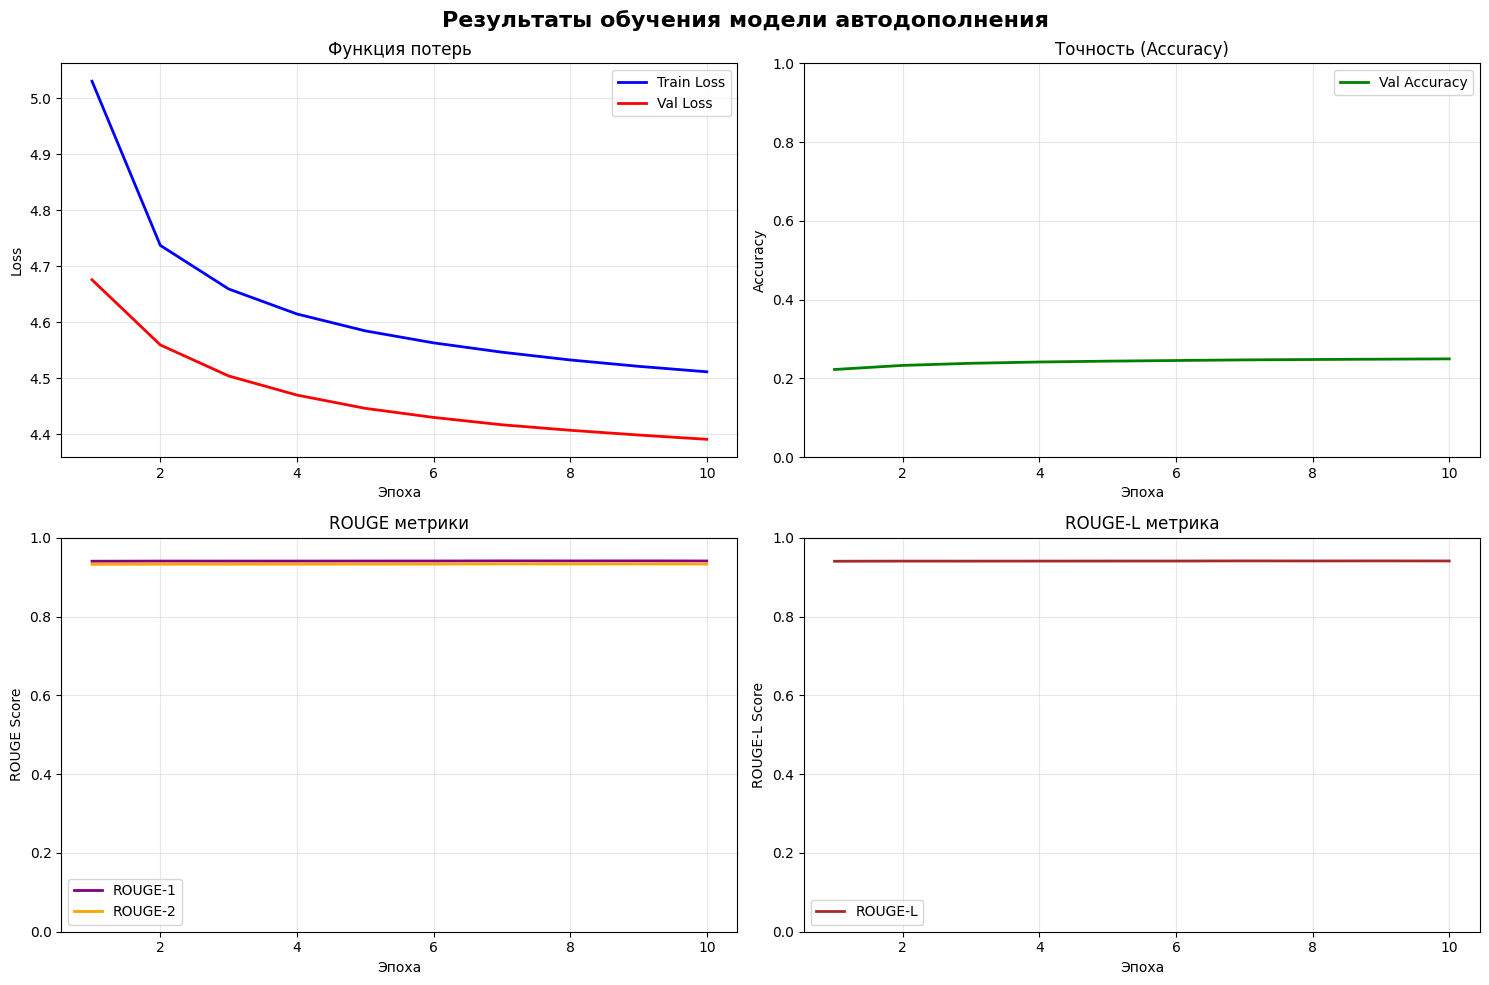


ИТОГОВЫЕ МЕТРИКИ ОБУЧЕНИЯ
Количество эпох: 10
Финальный Train Loss: 4.5116
Финальный Val Loss: 4.3911
Финальная Accuracy: 0.2496
Финальный ROUGE-1: 0.9412
Финальный ROUGE-2: 0.9333
Финальный ROUGE-L: 0.9412

Улучшение за обучение:
  Loss: +0.5186
  Accuracy: +0.0270
  ROUGE-1: +0.0006


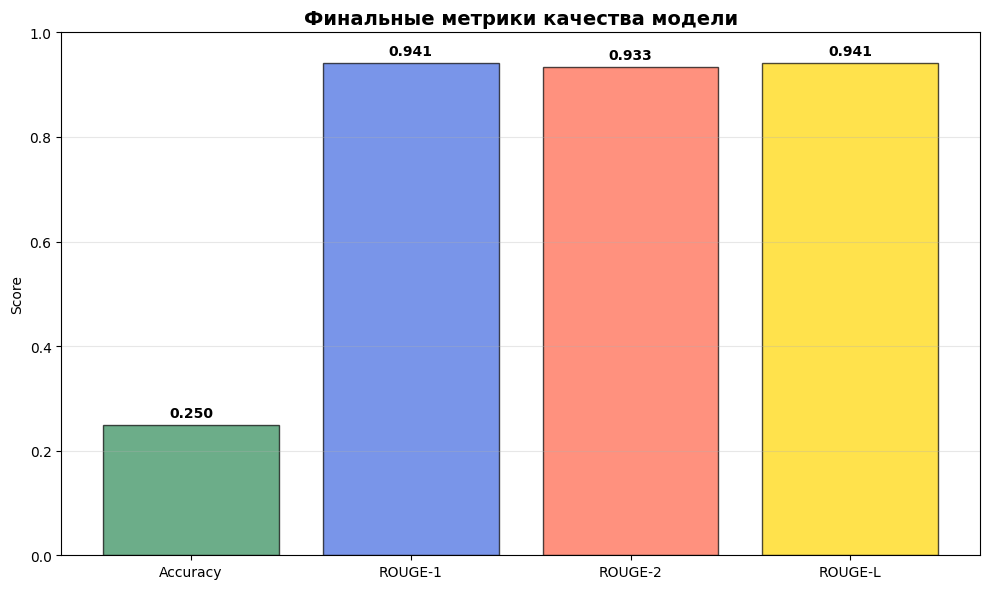


ПРИМЕРЫ ГЕНЕРАЦИИ - ЭПОХА 10

Пример 1: ✅ ПРАВИЛЬНО
Вход: ', late dinner, work, bed. my plan for'
Предсказано: 'the' (вероятность: 0.118)
Ожидалось: 'the'
Совпадение: True

Пример 2: ❌ НЕПРАВИЛЬНО
Вход: 'so gross and i wanted this to be a good weekend'
Предсказано: '.' (вероятность: 0.228)
Ожидалось: '!'
Совпадение: False

Пример 3: ❌ НЕПРАВИЛЬНО
Вход: 'just saw your wedding imgs. wowser!'
Предсказано: '' (вероятность: 0.266)
Ожидалось: 'cong'
Совпадение: False

Пример 4: ❌ НЕПРАВИЛЬНО
Вход: '##z hes goin bak to bein a celebrity'
Предсказано: '' (вероятность: 0.132)
Ожидалось: '.'
Совпадение: False

Пример 5: ❌ НЕПРАВИЛЬНО
Вход: ', pushups, shower, late dinner, work,'
Предсказано: 'and' (вероятность: 0.094)
Ожидалось: 'bed'
Совпадение: False


In [4]:
from src import train_complete_with_plots, save_model_with_metadata

# Запускаем обучение
results = train_complete_with_plots(
    model,
    train_loader,
    val_loader,
    tokenizer,
    optimizer,
    criterion,
    device,
    epochs
)

Как можно видеть, очевидна ошибка в функции оценки метрик ROUGE из-за того, что сравниваются практически верные последовательности - "I love this**" - "cake", "book", таким образом базово метрика очень высокая, т.к. отличается только одно слово. Однако прирост в 0.040 показывает что какое-то верное направление нам удалось нащупать в подборе параметров. 

# **Этапы сохранения и оценки результатов:**

In [ ]:
from src import save_model_with_metadata

save_model_with_metadata(
    model,
    results,
    tokenizer,
    train_loader,
    val_loader,
    model_name="LSTM_autocomplete",
    save_dir="./models"
)

Модель и метаданные сохранена в папку models

# Сравним результаты с трансформером GPT2 на тестовых данных:

In [8]:
from transformers import BertTokenizerFast

from src import ModelComparator

model.eval()

tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")
comparator = ModelComparator(
    model,
    tokenizer
)

print("Формируем тестовый Dataset")
test_dataset = NextTokenDataset(
    "./data/test.csv",
    sequence_length=7,
    min_sequence_length=10
)
print("Успешно!")
test_loader = DataLoader(
    test_dataset,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    batch_size=256,
    prefetch_factor=2)

results = comparator.evaluate_on_test_loader(test_loader, num_batches=256)

Загрузка DistilGPT2...
Модели загружены!
Формируем тестовый Dataset
Создано 5722 осмысленных примеров
Успешно!

ЧЕСТНОЕ СРАВНЕНИЕ НА TEST_LOADER
Оценка на 256 батчах...

 Пример 1:
   Вход: 'i love my kindle.'
   Истинное следующее слово: 'no'
   LSTM: '.' (0.284) ❌
   DistilGPT2: '
' (0.187) ❌

 Пример 2:
   Вход: 'i love my kindle. no'
   Истинное следующее слово: 'that'
   LSTM: 'i' (0.092) ❌
   DistilGPT2: ' matter' (0.082) ❌

 Пример 3:
   Вход: 'love my kindle. no that'
   Истинное следующее слово: 'the'
   LSTM: 'i' (0.302) ❌
   DistilGPT2: ' I' (0.121) ❌

 Пример 4:
   Вход: 'my kindle. no that the'
   Истинное следующее слово: 'd'
   LSTM: 'same' (0.020) ❌
   DistilGPT2: ' other' (0.012) ❌

 Пример 5:
   Вход: 'kindle. no that the d'
   Истинное следующее слово: '##x'
   LSTM: '##m' (0.176) ❌
   DistilGPT2: 'ork' (0.023) ❌

📊 РЕЗУЛЬТАТЫ НА 115 ПРИМЕРАХ:
   LSTM Accuracy: 0.2261
   DistilGPT2 Accuracy: 0.0957

🎯 ROUGE МЕТРИКИ (чем выше - тем лучше):
   LSTM ROUGE-1: 0.8872
   D

Вывод по экспериментам:

Наша модель как и GPT2 с трудом схватывают продолжение. Судя по accuracy LSTM угадывает каждое 4 слово, и для такого большого набора данных это может быть хорошим знаком, однако для итогового результата это очень низкий показатель. LSTM показала 22.6% accuracy против 9.6% у DistilGPT2, что в 2.4 раза лучше на задаче next-word prediction. При словаре 30K+ слов, где random baseline составляет 0.003%, текущий результат демонстрирует значительное обучение, однако требует оптимизации данных и архитектуры для production-качества.


Для улучшения качества модели, мне кажется следует:

1. Обратить внимание на предобработку исходных данных - удалось убрать множество мусора, однако, скорее всего напрашивается проверка залипания модели на частых словах - модель могла выучить частые слова и тем самым получить свою метрику.

```python
# Анализ предсказаний:
common_words = ['the', 'a', 'and', 'is', 'to', 'of', 'in', 'that', 'it', 'for']

def analyze_predictions(model, test_loader):
    common_word_predictions = 0
    total_predictions = 0
    
    for batch in test_loader:
        predictions = model(batch)
        # Считаем сколько раз модель предсказывает частые слова
        # Если > 30% - есть проблема залипания
```

2. Обратить внимание на усвоение данных моделью в зависимости от длин последовательностей. Проанализировав длины последовательностей в тексте, сперва я выбрал оптимальную длину для сохранения большей части текста, однако, возможно, следует сосредоточиться на "необходимом контексте" для расчетов в слоях модели, и установить различные длины последовательностей и проанализировать их влияние.

```python
# Эксперименты с длиной контекста:
context_lengths = [5, 10, 15, 20, 25]
# Анализ: accuracy vs context_length для оптимума
```

3. При всех прочих измениях напрашивается тренировка в районе 20-30 эпох для выхода в accuracy ~50-60% но для этого нужен производительный GPU, которым я на данный момент не обладаю. Напрашивается увеличение размера батча, эмбеддингов и скрытых слоев у модели, и хочется остановиться на 2-4 слоях LSTM. Проведение экспериментов на такой архитектуре требует хорошей вычислительной мощности, однако такой возможности пока нет.